In [ ]:
# Basic imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


import warnings
warnings.filterwarnings("ignore")

## 1.1 Load the data and preprocessing

In [16]:
# Load data
target_value = "Anomaly Scores"
data = pd.read_csv("cybersecurity_attacks.csv")
data.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


## 1.2 Handle missing values

In [17]:
data.columns[data.isnull().sum() != 0]

Index(['Malware Indicators', 'Alerts/Warnings', 'Proxy Information',
       'Firewall Logs', 'IDS/IPS Alerts'],
      dtype='object')

In [18]:
num_null_counts = data.isnull().sum()
null_cols = data.columns[num_null_counts != 0]
if len(null_cols) > 0:
    print("Data contains NaN values")
    display(num_null_counts[num_null_counts != 0])

else:
    print("Data does not contain NaN values")


Data contains NaN values


Malware Indicators    20000
Alerts/Warnings       20067
Proxy Information     19851
Firewall Logs         19961
IDS/IPS Alerts        20050
dtype: int64

In [ ]:
for col in null_cols:
    print(f"{col}: {data[col].nunique()} {data[col].unique()}")


Malware Indicators: 1 ['IoC Detected' nan]
Alerts/Warnings: 1 [nan 'Alert Triggered']
Proxy Information: 20148 ['150.9.97.135' nan '114.133.48.179' ... '60.51.30.46' '137.76.130.8'
 '112.169.115.139']
Firewall Logs: 1 ['Log Data' nan]
IDS/IPS Alerts: 1 [nan 'Alert Data']


In [6]:
data.groupby("Proxy Information")["Proxy Information"].count().sort_values(ascending=False)

Proxy Information
39.123.165.122    2
99.97.192.156     1
1.10.186.95       1
1.103.79.225      1
1.105.143.211     1
                 ..
1.198.246.92      1
1.198.27.132      1
1.20.16.131       1
1.200.8.153       1
99.249.145.160    1
Name: Proxy Information, Length: 20148, dtype: int64

### We can remove the colum proxy info because they're all unique values, 

### Ideas for future: could potentially split all the ip address segments into their own groups but I do not have enough domain knowledge to know if that would be useful

In [7]:
data = data.drop(null_cols, axis=1)
data.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Anomaly Scores,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,28.67,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,51.50,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,87.42,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,15.79,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,0.52,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",Firewall


In [8]:
for col in data.columns:
    display(data.groupby(col)[col].count().sort_values(ascending=False))

Timestamp
2022-04-17 20:05:34    2
2022-06-06 12:12:43    2
2022-06-11 14:28:15    2
2020-01-01 05:21:39    1
2020-01-01 06:37:14    1
                      ..
2023-10-11 12:29:23    1
2023-10-11 12:36:21    1
2023-10-11 17:44:41    1
2023-10-11 18:50:41    1
2020-01-01 03:29:20    1
Name: Timestamp, Length: 39997, dtype: int64

Source IP Address
99.50.246.63     1
99.54.94.213     1
99.6.24.231      1
99.60.173.124    1
99.60.219.73     1
                ..
1.10.74.49       1
1.100.115.5      1
1.101.138.199    1
1.103.126.230    1
1.103.203.179    1
Name: Source IP Address, Length: 40000, dtype: int64

Destination IP Address
99.51.95.207     1
99.53.242.226    1
99.54.125.108    1
99.54.142.207    1
99.58.215.130    1
                ..
1.101.117.52     1
1.101.24.101     1
1.102.176.87     1
1.103.183.132    1
1.105.159.177    1
Name: Destination IP Address, Length: 40000, dtype: int64

Source Port
41341    6
4779     5
60026    5
4622     5
53397    5
        ..
65393    1
65396    1
65401    1
65405    1
65406    1
Name: Source Port, Length: 29761, dtype: int64

Destination Port
34117    6
7508     6
55154    5
16503    5
30449    5
        ..
1096     1
1100     1
1101     1
1107     1
65465    1
Name: Destination Port, Length: 29895, dtype: int64

...

User Information
Heer Lad            6
Ishaan Chaudhari    6
Ishita Chaudry      5
Baiju Dugar         5
Akarsh Tripathi     5
                   ..
Arhaan Kuruvilla    1
Arhaan Loyal        1
Aaina Dash          1
Aaina De            1
Aaina Bahri         1
Name: User Information, Length: 32389, dtype: int64

Device Information
Mozilla/5.0 (compatible; MSIE 6.0; Windows NT 6.2; Trident/3.0)       35
Mozilla/5.0 (compatible; MSIE 5.0; Windows 98; Trident/4.1)           34
Mozilla/5.0 (compatible; MSIE 6.0; Windows CE; Trident/4.0)           33
Mozilla/5.0 (compatible; MSIE 5.0; Windows NT 5.2; Trident/4.1)       31
Mozilla/5.0 (compatible; MSIE 7.0; Windows NT 6.0; Trident/3.0)       31
                                                                      ..
Mozilla/5.0 (Android 1.1; Mobile; rv:53.0) Gecko/53.0 Firefox/53.0     1
Mozilla/5.0 (Android 1.1; Mobile; rv:54.0) Gecko/54.0 Firefox/54.0     1
Mozilla/5.0 (Android 1.1; Mobile; rv:58.0) Gecko/58.0 Firefox/58.0     1
Mozilla/5.0 (Android 1.1; Mobile; rv:6.0) Gecko/6.0 Firefox/6.0        1
Opera/9.99.(X11; Linux x86_64; zh-TW) Presto/2.9.166 Version/11.00     1
Name: Device Information, Length: 32104, dtype: int64

Network Segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: Network Segment, dtype: int64

Geo-location Data
Ghaziabad, Meghalaya          16
Kalyan-Dombivli, Jharkhand    15
Ghaziabad, Uttarakhand        14
Ghaziabad, Tripura            14
Aurangabad, Nagaland          13
                              ..
Visakhapatnam, Assam           1
Visakhapatnam, Bihar           1
Adoni, Meghalaya               1
Yamunanagar, Odisha            1
Yamunanagar, Uttarakhand       1
Name: Geo-location Data, Length: 8723, dtype: int64

Log Source
Firewall    20116
Server      19884
Name: Log Source, dtype: int64

remove cols that have mostly unique values

NOTE: you could likely split all of these columns into their own columns (127.0.0.1) -> (127), (0), (0), (1) etc.

In [19]:
rm_cols = ["Timestamp", "Source IP Address", "Destination IP Address", "Payload Data"]
data = data.drop(rm_cols, axis=1)
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,31225,17616,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,16811,53600,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,20018,32534,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,6131,26646,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [ ]:
# Seperate target feature data from the larger df
y_vals = data[target_value]
data = data.drop(target_value, axis=1)
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,31225,17616,ICMP,503,Data,HTTP,IoC Detected,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,16811,53600,UDP,306,Control,HTTP,IoC Detected,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,20018,32534,UDP,385,Data,HTTP,NaN,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,6131,26646,TCP,1462,Data,DNS,NaN,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


## 1.4 Feature Scaling

### Encode categorical data

In [21]:
encode_cols = ["Protocol", "Packet Type", "Traffic Type", "Attack Type", "Attack Signature", "Action Taken", "Severity Level", "User Information", "Device Information", "Network Segment", "Geo-location Data", "Log Source"]
for col in encode_cols:
    data[col] = data[col].astype('category')
    data[col] = data[col].cat.codes
    data[col] = data[col].astype('int64')
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,31225,17616,0,503,1,2,IoC Detected,NaN,2,1,2,1,22830,18202,0,3723,150.9.97.135,Log Data,NaN,1
1,17245,48166,0,1174,1,2,IoC Detected,NaN,2,0,0,1,27434,18188,1,1677,NaN,Log Data,NaN,0
2,16811,53600,2,306,0,2,IoC Detected,Alert Triggered,0,1,1,1,10139,18280,2,1707,114.133.48.179,Log Data,Alert Data,0
3,20018,32534,2,385,1,2,NaN,Alert Triggered,2,1,0,2,9216,4793,1,3750,NaN,NaN,Alert Data,0
4,6131,26646,1,1462,1,0,NaN,Alert Triggered,0,1,0,1,6462,17964,2,577,149.6.110.119,NaN,Alert Data,0


### Scale data (numeric data only)

In [28]:
scaler = StandardScaler()
numeric_data = data[['Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type',
       'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level',
       'User Information', 'Device Information', 'Network Segment',
       'Geo-location Data',
       'Log Source']]
X_scaled = scaler.fit_transform(numeric_data)
X_scaled

array([[-0.09403762, -0.83635746, -1.21937263, ..., -1.22855875,
        -0.24612521,  1.00581692],
       [-0.84726252,  0.80837614, -1.21937263, ..., -0.00413244,
        -1.05726911, -0.99421672],
       [-0.8706459 ,  1.10092875,  1.22732439, ...,  1.22029387,
        -1.0453755 , -0.99421672],
       ...,
       [-0.56386031, -0.43063856,  1.22732439, ...,  1.22029387,
         0.22922255,  1.00581692],
       [-0.69812615, -1.63923511,  1.22732439, ..., -0.00413244,
         1.03640191,  1.00581692],
       [ 0.92491727,  1.20725768, -1.21937263, ..., -1.22855875,
         0.84967231, -0.99421672]])

### 1.5 Applying PCA

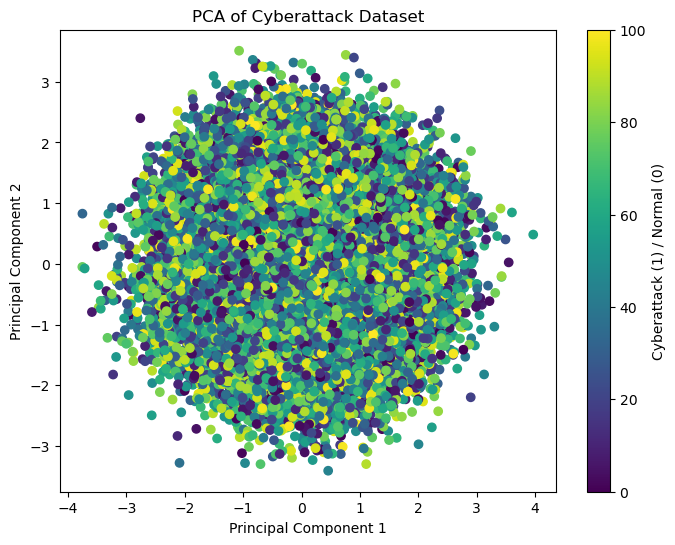

In [29]:
pca=PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)
#visualize components of PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_vals, cmap='viridis', marker='o')
plt.title('PCA of Cyberattack Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cyberattack (1) / Normal (0)')
plt.show()

## 2.1 Split data with 80/20 split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, 
    y_vals, 
    test_size=0.2, 
    random_state=42)

In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## 2.2 Train the models and 2.3 Evaluate the models
### SVR Poly kernel

In [33]:
svr_poly_params = {
    'degree': [1, 2, 3],
    'C': [1, 2, 3]
}

svr_poly = SVR(kernel="poly")
svr_poly_grid = GridSearchCV(svr_poly, svr_poly_params, cv=cv, scoring="r2", verbose=3)
svr_poly_grid.fit(X_train, y_train)

best_svr_poly = svr_poly_grid.best_estimator_
best_svr_poly.fit(X_train, y_train)
y_pred_poly = best_svr_poly.predict(X_test)
print("Poly SVR score: ", r2_score(y_test, y_pred_poly))


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ....................C=1, degree=1;, score=-0.001 total time=  21.3s
[CV 2/5] END ....................C=1, degree=1;, score=-0.002 total time=  22.0s
[CV 3/5] END ....................C=1, degree=1;, score=-0.002 total time=  22.0s
[CV 4/5] END ....................C=1, degree=1;, score=-0.003 total time=  21.8s
[CV 5/5] END ....................C=1, degree=1;, score=-0.001 total time=  21.9s
[CV 1/5] END ....................C=1, degree=2;, score=-0.006 total time=  22.3s
[CV 2/5] END ....................C=1, degree=2;, score=-0.008 total time=  20.8s
[CV 3/5] END ....................C=1, degree=2;, score=-0.009 total time=  22.7s
[CV 4/5] END ....................C=1, degree=2;, score=-0.009 total time=  21.7s
[CV 5/5] END ....................C=1, degree=2;, score=-0.008 total time=  21.5s
[CV 1/5] END ....................C=1, degree=3;, score=-0.014 total time=  21.5s
[CV 2/5] END ....................C=1, degree=3;, 

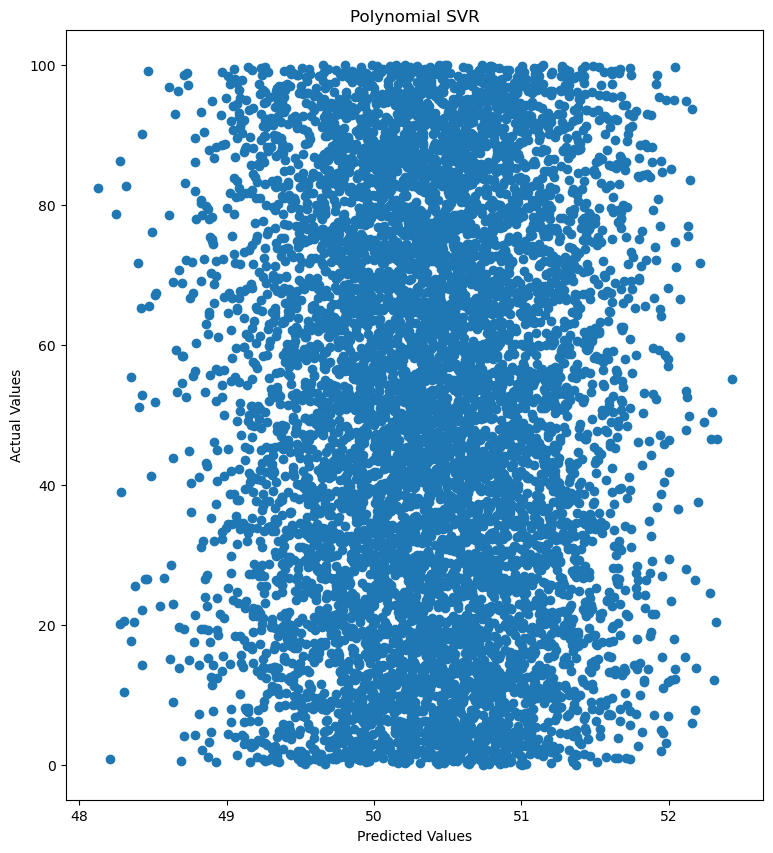

In [34]:
# Visualize regression accuracy
plt.figure(figsize=(9, 10))
plt.scatter(y_pred_poly, y_test)
plt.title('Polynomial SVR')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

### SVR rbf kernel

In [35]:
svr_rbf_params = {
    'degree': [1, 2, 3],
    'C': [1, 2, 3]
}

svr_rbf = SVR(kernel="rbf")
svr_rbf_grid = GridSearchCV(svr_rbf, svr_rbf_params, cv=cv, scoring="r2", verbose=3)
svr_rbf_grid.fit(X_train, y_train)

best_svr_rbf = svr_rbf_grid.best_estimator_
best_svr_rbf.fit(X_train, y_train)
y_pred_rbf = best_svr_rbf.predict(X_test)
print("RBF SVR score: ", r2_score(y_test, y_pred_rbf))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ....................C=1, degree=1;, score=-0.004 total time=  32.3s
[CV 2/5] END ....................C=1, degree=1;, score=-0.006 total time=  32.5s
[CV 3/5] END ....................C=1, degree=1;, score=-0.008 total time=  32.0s
[CV 4/5] END ....................C=1, degree=1;, score=-0.008 total time=  32.0s
[CV 5/5] END ....................C=1, degree=1;, score=-0.006 total time=  31.8s
[CV 1/5] END ....................C=1, degree=2;, score=-0.004 total time=  32.3s
[CV 2/5] END ....................C=1, degree=2;, score=-0.006 total time=  31.7s
[CV 3/5] END ....................C=1, degree=2;, score=-0.008 total time=  32.0s
[CV 4/5] END ....................C=1, degree=2;, score=-0.008 total time=  31.8s
[CV 5/5] END ....................C=1, degree=2;, score=-0.006 total time=  32.1s
[CV 1/5] END ....................C=1, degree=3;, score=-0.004 total time=  31.9s
[CV 2/5] END ....................C=1, degree=3;, 

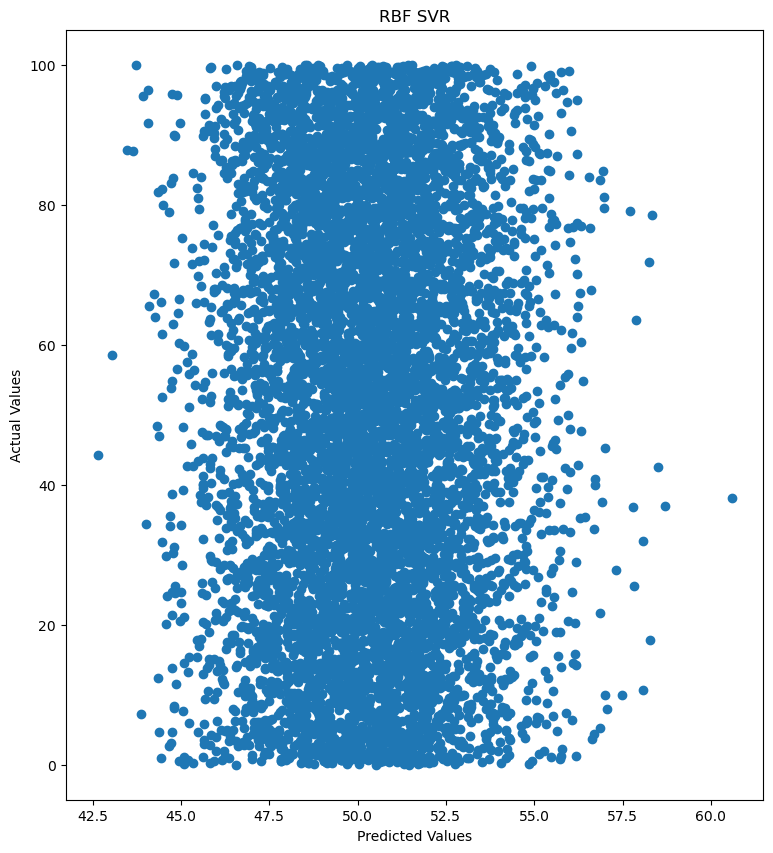

In [37]:
# Visualize regression accuracy
plt.figure(figsize=(9, 10))
plt.scatter(y_pred_rbf, y_test)
plt.title('RBF SVR')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

### RF

In [38]:
rf_params = {
    'n_estimators': [25, 50, 100],
    'max_depth': [5, 10, 20],
}


rf = RandomForestRegressor()
rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring="r2", verbose=3)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
print("RF score: ", r2_score(y_test, y_pred_rf))


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ......max_depth=5, n_estimators=25;, score=0.000 total time=   2.9s
[CV 2/5] END .....max_depth=5, n_estimators=25;, score=-0.001 total time=   3.0s
[CV 3/5] END .....max_depth=5, n_estimators=25;, score=-0.002 total time=   2.9s
[CV 4/5] END .....max_depth=5, n_estimators=25;, score=-0.003 total time=   2.8s
[CV 5/5] END .....max_depth=5, n_estimators=25;, score=-0.001 total time=   2.9s
[CV 1/5] END .....max_depth=5, n_estimators=50;, score=-0.001 total time=   5.8s
[CV 2/5] END .....max_depth=5, n_estimators=50;, score=-0.001 total time=   5.3s
[CV 3/5] END .....max_depth=5, n_estimators=50;, score=-0.001 total time=   5.4s
[CV 4/5] END .....max_depth=5, n_estimators=50;, score=-0.001 total time=   5.3s
[CV 5/5] END .....max_depth=5, n_estimators=50;, score=-0.001 total time=   5.3s
[CV 1/5] END ....max_depth=5, n_estimators=100;, score=-0.000 total time=  10.9s
[CV 2/5] END ....max_depth=5, n_estimators=100;, 

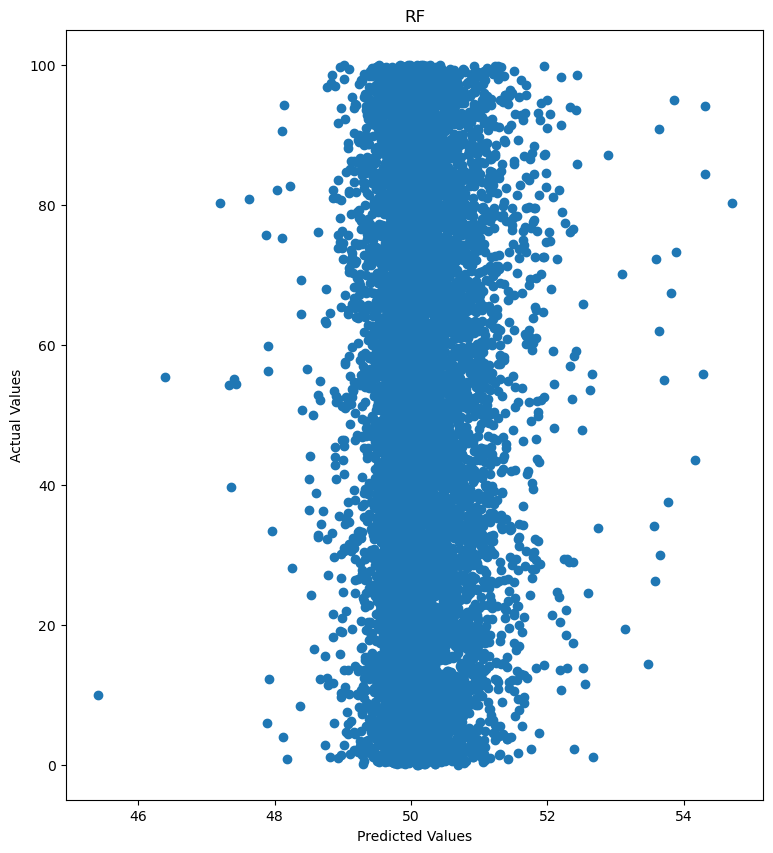

In [40]:
# Visualize regression accuracy
plt.figure(figsize=(9, 10))
plt.scatter(y_pred_rf, y_test)
plt.title('RF')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

## 2.4 Discussion